## cos𝜽* calculation at a reco-level using AK4 jets instead of AK8 jets. 

In [1]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [25]:
# Datasets:
#/BulkGravToWW_narrow_M-*_13TeV-madgraph/*NanoAODv7*/NANOAODSIM
#/RSGravToWWToWlepWhad_width0p1_M-*_TuneCUETP8M1_13TeV-madgraph-pythia8/*NanoAODv3*/NANOAODSIM


# When having a large number of files it is useful to put the list on a separate file.
# import json

# with open("semileptonic_notebooks/samples.json", 'r') as sample_file:
#     fileset = json.load(sample_file)

# for sample in fileset:
#     print(sample)

# For now we are only testing on a limited number of files so they are just listed here
fileset = {
    'BulkGravToWW': {
        'files': [
            # M-500 sample
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-500_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/0E8E186D-2315-C14F-BC4D-2046C6C884A9.root',

            # M-600 sample
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-600_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/70000/35A2E78F-19D2-BE46-A8D0-4F8D1BCF5283.root',

            # M-1000 sample
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root',
        ],
        'metadata': {
            'is_mc': True,
        },
    },
    'RSGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv3/RSGravToWWToWlepWhad_width0p1_M-1200_TuneCUETP8M1_13TeV-madgraph-pythia8/NANOAODSIM/PUMoriond17_94X_mcRun2_asymptotic_v3-v1/60000/4442437A-52BB-E811-A8DA-90E2BACC5EEC.root': "Events",
          },
        'metadata': {
            'is_mc': 'True',
        },
    }
}

In [27]:
# This step takes some time because it is loading the events
test_dataset_bulk = 'BulkGravToWW'
events = NanoEventsFactory.from_root(
    fileset[test_dataset_bulk]['files'],
    entry_stop = 1000,
    metadata = fileset[test_dataset_bulk]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

# test_dataset_rs = 'RSGravToWW'
# events = NanoEventsFactory.from_root(
#     fileset[test_dataset_rs]['files'],
#     entry_stop =1000,
#     metadata = fileset[test_dataset_rs]['metadata'],
#     schemaclass = NanoAODSchema,
#     delayed = False,
# ).events()

ValueError: Specification of treename by argument to from_root is no longer supported in coffea 2023.
            Please use one of the allowed types for "files" specified by uproot: https://github.com/scikit-hep/uproot5/blob/v5.1.2/src/uproot/_dask.py#L109-L132
            

#### ––– *Step 1: Tight Lepton Selection* –––

In [4]:
muons = events.Muon
electrons = events.Electron

# -- Tight lepton selection --
tight_muon = muons[
    (muons.pt > 30) & 
    (abs(muons.eta) < 2.4) & 
    (muons.tightId)
]

print(len(ak.flatten(tight_muon)), 'out of' ,len(ak.flatten(muons)), 'muons pass the tight selection')

tight_electron = electrons[
    (electrons.pt > 35) & 
    (abs(electrons.eta) < 2.4) & 
    (electrons.cutBased >= 3)
]

print(len(ak.flatten(tight_electron)), 'out of' ,len(ak.flatten(electrons)), 'electrons pass the tight selection')


# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_muon.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_electron.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

266 out of 724 muons pass the tight selection
195 out of 897 electrons pass the tight selection


In [5]:
# Thresholds
electron_pt_threshold = 40
muon_pt_threshold = 40
pt_miss_threshold = 40

# Tight leptons (using previous selections)
muons_tight = tight_muon[tight_muon.pt > muon_pt_threshold]
electrons_tight = tight_electron[tight_electron.pt > electron_pt_threshold]

# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events passed the tight lepton selection and loose veto.")

323 events passed the tight lepton selection and loose veto.


In [6]:
# -- Merge leptons into a single collection --
tight_leptons = ak.with_name(
    ak.concatenate([tight_muon, tight_electron], axis=1),
    "PtEtaPhiMCandidate"
)
print(len(ak.flatten(tight_leptons)))

461


#### ––– *Step 2: AK4 jet cleaning* –––

In [7]:
# Select AK4 jets (baseline)
ak4_jets = events.Jet[(events.Jet.pt > 30) & (abs(events.Jet.eta) < 2.4)]

# Select AK8 jets (for overlap removal)
ak8_jets = events.FatJet[(events.FatJet.pt > 200) & (abs(events.FatJet.eta) < 2.4)]

# -- Helper function for ΔR --
def delta_r_fct(obj1, obj2):
    delta_phi = np.abs(obj1.phi - obj2.phi)
    delta_phi = np.where(delta_phi > np.pi, 2*np.pi - delta_phi, delta_phi)
    delta_eta = obj1.eta - obj2.eta
    return np.sqrt(delta_eta**2 + delta_phi**2)

# --- ΔR cleaning against tight leptons ---
pairs_ak4_lep = ak.cartesian({"jet": ak4_jets, "lep": tight_leptons}, axis=1, nested=True)
delta_r_lep = delta_r_fct(pairs_ak4_lep.jet, pairs_ak4_lep.lep)
cleanmask_lep = ak.all(delta_r_lep > 0.8, axis=2)
ak4_jets_lepclean = ak4_jets[cleanmask_lep]

# --- ΔR cleaning against AK8 jets ---
pairs_ak4_ak8 = ak.cartesian({"ak4": ak4_jets_lepclean, "ak8": ak8_jets}, axis=1, nested=True)
delta_r_ak8 = delta_r_fct(pairs_ak4_ak8.ak4, pairs_ak4_ak8.ak8)
cleanmask_ak8 = ak.all(delta_r_ak8 > 0.8, axis=2)

# Final cleaned AK4 jets
ak4_jets_clean = ak4_jets_lepclean[cleanmask_ak8]

<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_196/151260788.py:26: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Jet $\eta$')
/tmp/ipykernel_196/151260788.py:28: SyntaxWarning: invalid escape sequence '\e'
  plt.title('AK4 Jet $\eta$')


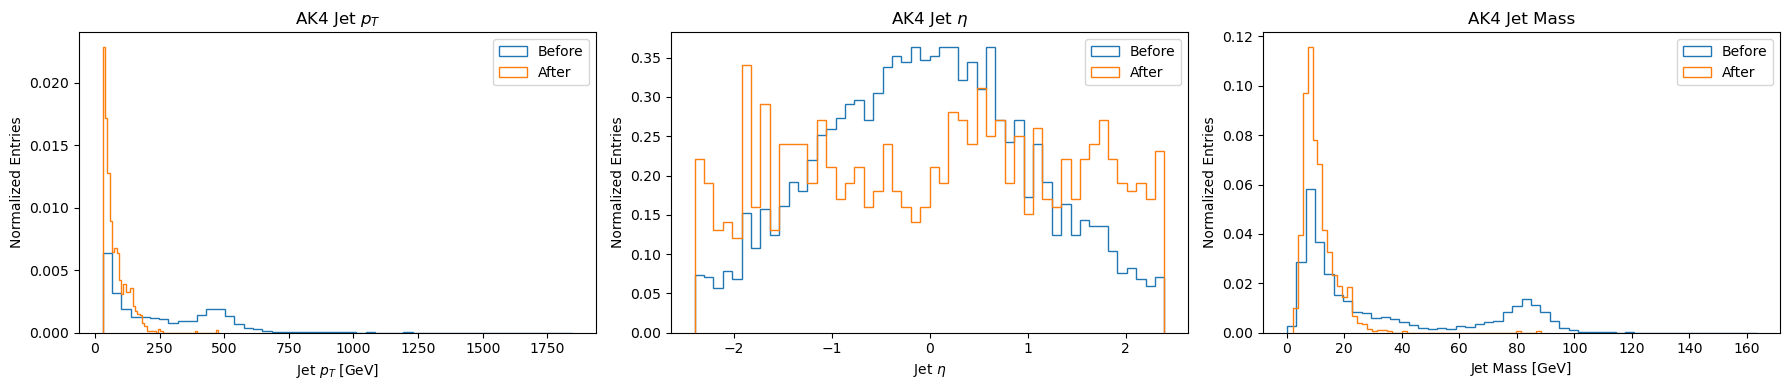

In [8]:
# Before cleaning
pt_before = ak.flatten(ak4_jets.pt)
eta_before = ak.flatten(ak4_jets.eta)
mass_before = ak.flatten(ak4_jets.mass)

# After cleaning
pt_after = ak.flatten(ak4_jets_clean.pt)
eta_after = ak.flatten(ak4_jets_clean.eta)
mass_after = ak.flatten(ak4_jets_clean.mass)

plt.figure(figsize=(18, 4))

# pT
plt.subplot(1, 3, 1)
plt.hist(pt_before, bins=50, histtype='step', label='Before', density=True)
plt.hist(pt_after, bins=50, histtype='step', label='After', density=True)
plt.xlabel('Jet $p_T$ [GeV]')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet $p_T$')
plt.legend()

# Eta
plt.subplot(1, 3, 2)
plt.hist(eta_before, bins=50, histtype='step', label='Before', density=True)
plt.hist(eta_after, bins=50, histtype='step', label='After', density=True)
plt.xlabel('Jet $\eta$')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet $\eta$')
plt.legend()

# Mass
plt.subplot(1, 3, 3)
plt.hist(mass_before, bins=50, histtype='step', label='Before', density=True)
plt.hist(mass_after, bins=50, histtype='step', label='After', density=True)
plt.xlabel('Jet Mass [GeV]')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet Mass')
plt.legend()

plt.tight_layout()
plt.show()

#### *––– Step 3: Define Semi-Leptonic and Hadronic Categories Using AK4 Jets –––*

In [9]:
# define hadronic and semi-leptonic masks based on leptons
n_tight_muons = ak.num(tight_muon)
n_tight_electrons = ak.num(tight_electron)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(ak4_jets_clean) >= 2)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(ak4_jets_clean) >= 4))

# Apply masks to events and AK4 jets
ak4_jets_had = ak4_jets_clean[fully_hadronic_mask]
ak4_jets_semi = ak4_jets_clean[semi_leptonic_mask]

#### *––– Step 4: Pair jets per event –––*

In [10]:
# --- SEMI-LEPTONIC: use leading + subleading AK4 jets ---
ak4_jets_sl = ak4_jets_clean[ak.num(ak4_jets_clean) >= 2]
lead_ak4_sl = ak4_jets_sl[:, 0]
sublead_ak4_sl = ak4_jets_sl[:, 1]

# --- HADRONIC: best dijet pair from top 4 jets (closest to W mass) ---
ak4_jets_had = ak4_jets_clean[ak.num(ak4_jets_clean) >= 4]
ak4_top4 = ak4_jets_had[:, :4]

ak4_pairs = ak.combinations(ak4_top4, 2, fields=["j1", "j2"])
pair_masses = (ak4_pairs.j1 + ak4_pairs.j2).mass
best_idx = ak.argmax(pair_masses, axis=1)

# Clean extraction of best dijet pair (1-to-1 mapping, no jagged nesting)
j1_had = ak4_pairs.j1[best_idx]
j2_had = ak4_pairs.j2[best_idx]

#### *–––Step 5: Compute cosθ** –––

In [11]:
# --- Build Lorentz vectors for semi-leptonic ---
def build_lorentz_vectors(jets):
    return vector.array({
        "px": jets.pt * np.cos(jets.phi),
        "py": jets.pt * np.sin(jets.phi),
        "pz": jets.pt * np.sinh(jets.eta),
        "E":  np.sqrt((jets.pt * np.cosh(jets.eta))**2 + jets.mass**2),
    })

In [17]:
# -- Semi-leptonic category: leading + subleading AK4 jets --
q1_sl = build_lorentz_vectors(lead_ak4_sl)
q2_sl = build_lorentz_vectors(sublead_ak4_sl)
ak4pairs_sl = list(zip(q1_sl, q2_sl))  # List of (vec1, vec2) tuples

# -- Fully hadronic category: best dijet pair from top 4 jets --
# Flatten the selected jets (from best dijet pair)
j1_had_flat = ak.flatten(j1_had)
j2_had_flat = ak.flatten(j2_had)
# Now safely build Lorentz vectors
q1_had = build_lorentz_vectors(j1_had_flat)
q2_had = build_lorentz_vectors(j2_had_flat)
# Form (vec1, vec2) pairs
ak4pairs_had = list(zip(q1_had, q2_had))

In [18]:
# -- Compute cos(θ*) for Given AK4 Jet Pairs --
def compute_cos_theta_star_from_ak4pairs(jet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(jet_pairs):
        try:
            w_lab = vec1 + vec2
            if w_lab.mass < np.abs(1e-3) or w_lab.E <= np.abs(1e-6):
                n_skipped += 1
                continue

            # Boost vec1 into W rest frame
            q1_rest = vec1.boost_beta3(-w_lab.to_beta3())

            # Compute unit 3-momentum vector of q1 in W rest frame
            q_vec = np.array([q1_rest.px, q1_rest.py, q1_rest.pz])
            q_unit = q_vec / np.linalg.norm(q_vec)

            # Compute unit boost direction vector (W momentum in lab)
            w_vec = np.array([w_lab.px, w_lab.py, w_lab.pz])
            w_unit = w_vec / np.linalg.norm(w_vec)

            # Cos(theta*) = angle between decay product and boost axis
            cos_theta = np.dot(q_unit, w_unit)

            cos_theta_star.append(cos_theta)
            n_success += 1

        except Exception:
            n_skipped += 1

    print(f"[{category_name}] Computed cosθ* for {n_success} AK4 jet pairs, Skipped: {n_skipped}")
    
    if len(cos_theta_star) > 0:
        cos_array = np.array(cos_theta_star)
        print(f"[{category_name}] cosθ* range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
        print(f"[{category_name}] Histogram counts (neg, zero, pos): "
              f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")

    return np.array(cos_theta_star)

In [19]:
cos_theta_star_sl = compute_cos_theta_star_from_ak4pairs(ak4pairs_sl, category_name="AK4 Semi-leptonic")
cos_theta_star_had = compute_cos_theta_star_from_ak4pairs(ak4pairs_had, category_name="AK4 Fully hadronic")

[AK4 Semi-leptonic] Computed cosθ* for 263 AK4 jet pairs, Skipped: 0
[AK4 Semi-leptonic] cosθ* range: min = -0.812, max = 0.991
[AK4 Semi-leptonic] Histogram counts (neg, zero, pos): 81, 0, 182
[AK4 Fully hadronic] Computed cosθ* for 204 AK4 jet pairs, Skipped: 0
[AK4 Fully hadronic] cosθ* range: min = -0.891, max = 0.914
[AK4 Fully hadronic] Histogram counts (neg, zero, pos): 67, 0, 137


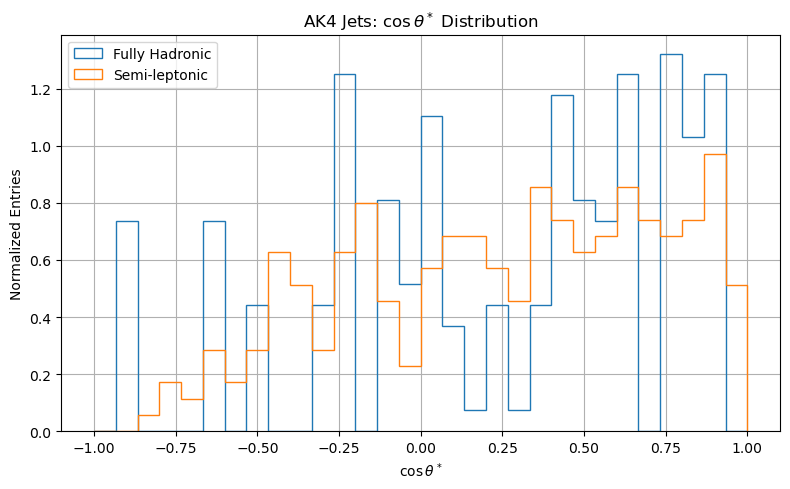

In [22]:
plt.figure(figsize=(8, 5))

# Histogram overlays (normalized)
plt.hist(cos_theta_star_had, bins=30, range=(-1, 1), histtype='step', label='Fully Hadronic', density=True)
plt.hist(cos_theta_star_sl, bins=30, range=(-1, 1), histtype='step', label='Semi-leptonic', density=True)

plt.xlabel(r'$\cos\theta^*$')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jets: $\\cos\\theta^*$ Distribution')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# print("lead_ak4_sl example:", ak4_jets_semi[0])
# print("ak.num(ak4_jets_semi):", ak.num(ak4_jets_semi))

In [33]:
# print(ak4_jets_semi[0].pt)  # Should match lead_ak4_sl[0].pt
# print(ak4_jets_had[0].pt)   # Should match lead_ak4_had[0].pt

In [34]:
# print("SL pt example:", lead_ak4_sl.pt)
# print("Had pt example:", lead_ak4_had.pt)